In [12]:
# --- CONFIGURAÇÃO ---
CSV_SOURCES = {
    "Python (OpenCV)": "csvs_py/**/results_*.csv",   # Ajuste conforme seu padrão de salvamento
    "C++ (OpenCV)": "csvs_cpp/**/results_*.csv", # Exemplo futuro
    #"Java (OpenCV)": "csvs_java/**/results_*.csv" # Exemplo futuro
}

In [19]:
def load_data():
    all_data = []
    
    for language, pattern in CSV_SOURCES.items():
        # Busca recursiva de arquivos
        files = glob.glob(pattern, recursive=True)
        
        if not files:
            print(f"⚠️ Aviso: Nenhum CSV encontrado para {language} no padrão '{pattern}'")
            continue
            
        for f in files:
            try:
                df = pd.read_csv(f)
                df['Language'] = language
                if "russian" in f:
                    df['Model'] = "Russian Plate"
                elif "16stages" in f:
                    df['Model'] = "Rus 16 Stages"
                else:
                    df['Model'] = "Unknown"
                
                all_data.append(df)
            except Exception as e:
                print(f"Erro ao ler {f}: {e}")
    
    if not all_data:
        return pd.DataFrame()
        
    return pd.concat(all_data, ignore_index=True)

df = load_data()

In [21]:
df.head()

,file,type,dataset,detected_count,time_ns,first_x,first_y,first_w,first_h,Language,Model
0,1187019.jpg,Brazil,DS1,1,145228400,2352,1466,632,158,Python (OpenCV),Unknown
1,1187019_labelled.jpg,Brazil,DS1,1,139617800,1988,1568,179,45,Python (OpenCV),Unknown
2,1792023.jpg,Brazil,DS1,1,130486700,1532,1202,167,42,Python (OpenCV),Unknown
3,1792023_labelled.jpg,Brazil,DS1,1,131657700,1532,1202,167,42,Python (OpenCV),Unknown
4,2114000.jpg,Brazil,DS1,4,122671400,3507,1339,246,62,Python (OpenCV),Unknown


In [14]:

def print_statistics(df):
    if df.empty: return

    print("\n" + "="*80)
    print(f"{'RESUMO ESTATÍSTICO PARA O ARTIGO':^80}")
    print("="*80)

    # Agrupa por Linguagem e Modelo Haar
    grouped = df.groupby(['Language', 'Model'])

    for (lang, model), group in grouped:
        total_imgs = len(group)
        total_detections = group['detected_count'].sum()
        empty_frames = group[group['detected_count'] == 0].shape[0]
        
        # Tempo em ms
        times_ms = group['time_ns'] / 1_000_000.0
        
        print(f"\n🔹 LINGUAGEM: {lang} | MODELO: {model}")
        print("-" * 50)
        print(f"• Total de Imagens Processadas: {total_imgs}")
        print(f"• Total de Detecções:           {total_detections}")
        print(f"• Imagens sem detecção (Vazio): {empty_frames} ({empty_frames/total_imgs*100:.1f}%)")
        print("-" * 50)
        print("  MÉTRICAS DE TEMPO (ms):")
        print(f"    - Média:         {times_ms.mean():.4f} ms")
        print(f"    - Mediana:       {times_ms.median():.4f} ms")
        print(f"    - Desvio Padrão: {times_ms.std():.4f} ms")
        print(f"    - Mínimo:        {times_ms.min():.4f} ms")
        print(f"    - Máximo:        {times_ms.max():.4f} ms")
        print("-" * 50)
        print("  MÉTRICAS DE DETECÇÃO (Qtd/img):")
        print(f"    - Média:         {group['detected_count'].mean():.4f}")
        print(f"    - Desvio Padrão: {group['detected_count'].std():.4f}")
        print("="*80)


In [15]:

def generate_plots(df):
    if df.empty: return
    
    # Converte para ms para os gráficos
    df['time_ms'] = df['time_ns'] / 1_000_000.0
    
    sns.set_theme(style="whitegrid")
    
    # 1. Boxplot Comparativo de Tempo (O mais importante para o artigo)
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Language', y='time_ms', hue='Model', data=df, showfliers=False) # showfliers=False esconde outliers extremos para limpar o gráfico
    plt.title('Comparação de Tempo de Processamento por Linguagem', fontsize=14)
    plt.ylabel('Tempo de Execução (ms)')
    plt.xlabel('Linguagem')
    plt.savefig('graphs/grafico_tempo_boxplot.png', dpi=300)
    print("📊 Gráfico salvo: graphs/grafico_tempo_boxplot.png")

    # 2. Violin Plot (Mostra a distribuição/densidade do tempo)
    plt.figure(figsize=(10, 6))
    sns.violinplot(x='Language', y='time_ms', hue='Model', data=df, split=True, inner="quart")
    plt.title('Distribuição de Densidade do Tempo de Execução', fontsize=14)
    plt.ylabel('Tempo de Execução (ms)')
    plt.savefig('graphs/grafico_tempo_violin.png', dpi=300)
    print("📊 Gráfico salvo: graphs/grafico_tempo_violin.png")

    # 3. Barplot de Contagem de Detecções (Acurácia/Sensibilidade)
    plt.figure(figsize=(10, 6))
    detection_sum = df.groupby(['Language', 'Model'])['detected_count'].mean().reset_index()
    sns.barplot(x='Language', y='detected_count', hue='Model', data=detection_sum)
    plt.title('Média de Objetos Detectados por Imagem', fontsize=14)
    plt.ylabel('Média de Detecções')
    plt.ylim(0, df['detected_count'].max() + 0.5)
    plt.savefig('graphs/grafico_deteccoes_media.png', dpi=300)
    print("📊 Gráfico salvo: graphs/grafico_deteccoes_media.png")

In [16]:

def main():
    print("📂 Carregando dados de todos os CSVs...")
    df = load_data()
    
    if df.empty:
        print("❌ Nenhum dado encontrado. Verifique os caminhos em CSV_SOURCES.")
        return

    # Gera o relatório de texto no terminal
    print_statistics(df)
    
    # Gera os gráficos visuais
    generate_plots(df)

📂 Carregando dados de todos os CSVs...

                        RESUMO ESTATÍSTICO PARA O ARTIGO                        

🔹 LINGUAGEM: C++ (OpenCV) | MODELO: Unknown
--------------------------------------------------
• Total de Imagens Processadas: 33480
• Total de Detecções:           14607
• Imagens sem detecção (Vazio): 25536 (76.3%)
--------------------------------------------------
  MÉTRICAS DE TEMPO (ms):
    - Média:         23.6616 ms
    - Mediana:       7.2511 ms
    - Desvio Padrão: 58.4981 ms
    - Mínimo:        0.0000 ms
    - Máximo:        911.7009 ms
--------------------------------------------------
  MÉTRICAS DE DETECÇÃO (Qtd/img):
    - Média:         0.4363
    - Desvio Padrão: 1.2440

🔹 LINGUAGEM: Python (OpenCV) | MODELO: Unknown
--------------------------------------------------
• Total de Imagens Processadas: 33480
• Total de Detecções:           14607
• Imagens sem detecção (Vazio): 25536 (76.3%)
--------------------------------------------------
  MÉTRICAS D

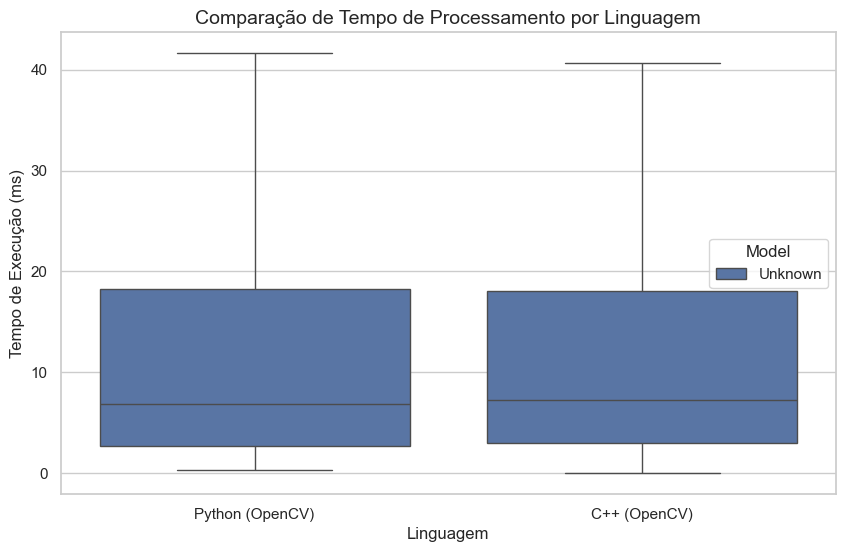

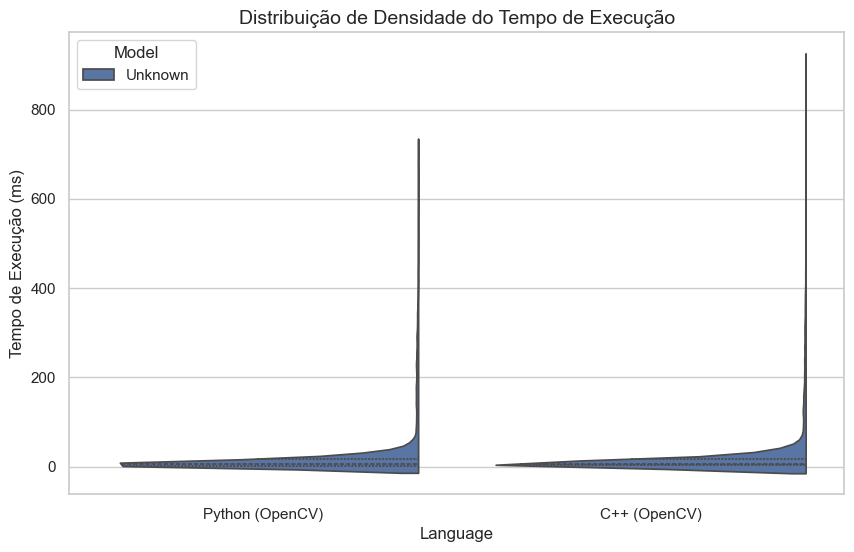

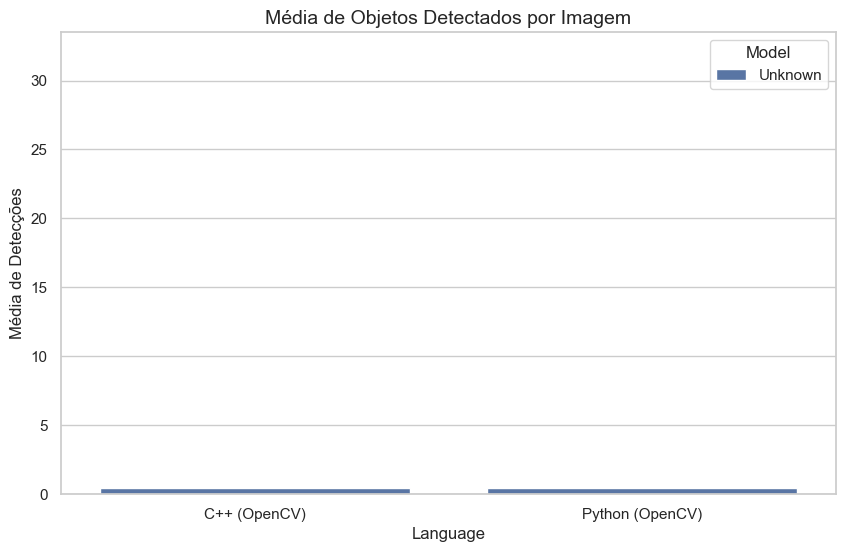

In [17]:

if __name__ == "__main__":
    main()